In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups

# Chargement du dataset 20 Newsgroups
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

print(f"Nombre de documents : {len(newsgroups.data)}")
print(f"Nombre de catégories : {len(newsgroups.target_names)}")
print(f"\nCatégories :")
for i, cat in enumerate(newsgroups.target_names):
    print(f"  {i:2d}. {cat}")

Nombre de documents : 18846
Nombre de catégories : 20

Catégories :
   0. alt.atheism
   1. comp.graphics
   2. comp.os.ms-windows.misc
   3. comp.sys.ibm.pc.hardware
   4. comp.sys.mac.hardware
   5. comp.windows.x
   6. misc.forsale
   7. rec.autos
   8. rec.motorcycles
   9. rec.sport.baseball
  10. rec.sport.hockey
  11. sci.crypt
  12. sci.electronics
  13. sci.med
  14. sci.space
  15. soc.religion.christian
  16. talk.politics.guns
  17. talk.politics.mideast
  18. talk.politics.misc
  19. talk.religion.misc


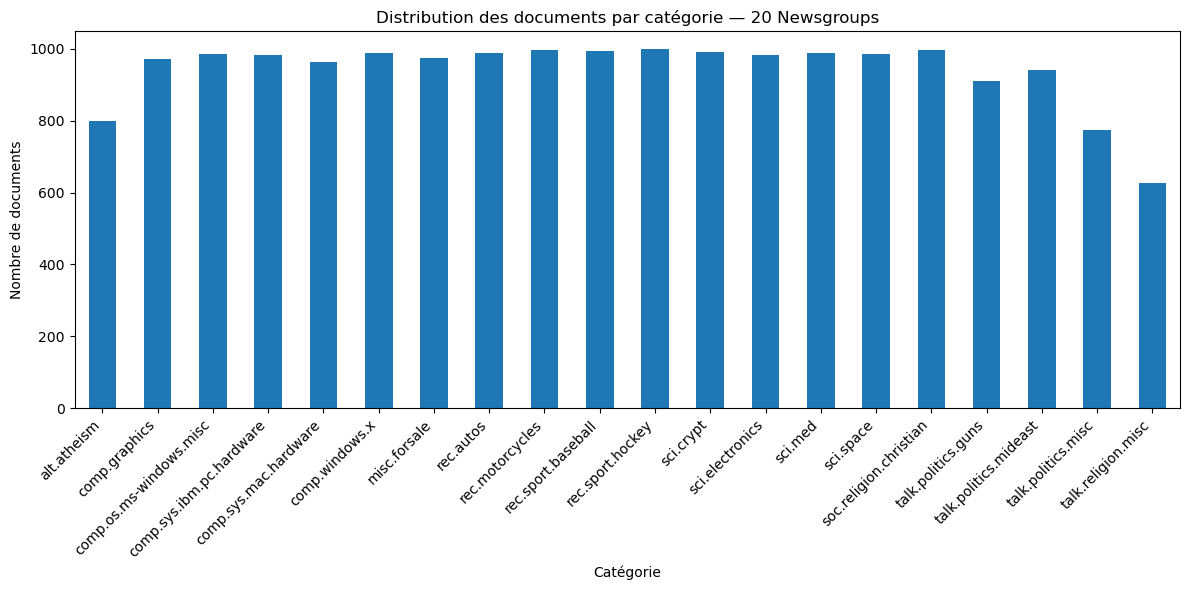

category
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


In [9]:
# Distribution des catégories
df = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target,
    'category': [newsgroups.target_names[i] for i in newsgroups.target]
})

plt.figure(figsize=(12, 6))
df['category'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des documents par catégorie — 20 Newsgroups')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df['category'].value_counts().sort_index())

Statistiques sur la longueur des textes (en mots) :
count    18846.000000
mean       181.637748
std        501.333800
min          0.000000
25%         40.000000
50%         83.000000
75%        166.000000
max      11765.000000
Name: text_length, dtype: float64


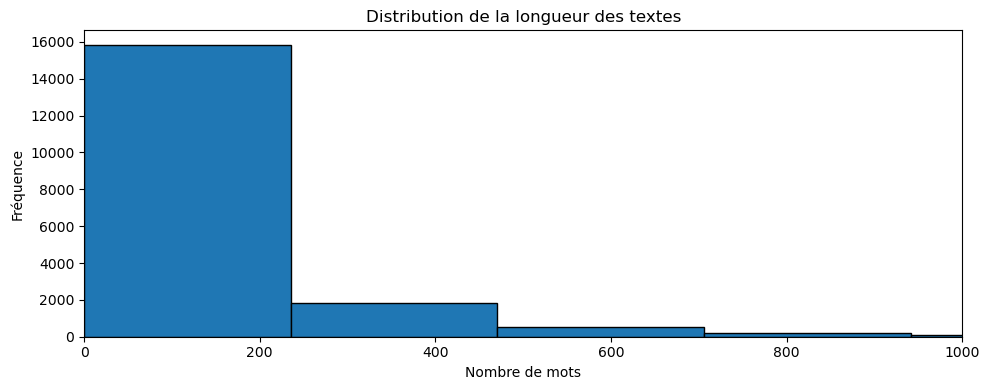


--- Exemple de document (cat: sci.space) ---
AW&ST  had a brief blurb on a Manned Lunar Exploration confernce
May 7th  at Crystal City Virginia, under the auspices of AIAA.

Does anyone know more about this?  How much, to attend????

Anyone want to go?


In [10]:
# Longueur des textes
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print("Statistiques sur la longueur des textes (en mots) :")
print(df['text_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=50, edgecolor='black')
plt.title('Distribution de la longueur des textes')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

# Quelques exemples
print("\n--- Exemple de document (cat: sci.space) ---")
sample = df[df['category'] == 'sci.space']['text'].iloc[0]
print(sample[:500])

In [11]:
# Stratégie pour la détection d'anomalies :
# On définit des catégories "normales" et des catégories "anomalies"

# Catégories normales : topics scientifiques et informatique
normal_categories = [
    'sci.space', 'sci.med', 'sci.electronics', 'sci.crypt',
    'comp.graphics', 'comp.sys.mac.hardware', 'comp.sys.ibm.pc.hardware'
]

# Catégories anomalies : topics hors distribution
anomaly_categories = [
    'talk.politics.guns', 'talk.politics.mideast',
    'talk.religion.misc', 'alt.atheism'
]

df_normal = df[df['category'].isin(normal_categories)].copy()
df_anomaly = df[df['category'].isin(anomaly_categories)].copy()

df_normal['label_ad'] = 0  # normal
df_anomaly['label_ad'] = 1  # anomalie

print(f"Documents normaux : {len(df_normal)}")
print(f"Documents anomalies : {len(df_anomaly)}")
print(f"Ratio anomalies : {len(df_anomaly) / (len(df_normal) + len(df_anomaly)):.2%}")

# Dataset final
df_final = pd.concat([df_normal, df_anomaly]).reset_index(drop=True)
print(f"\nDataset final : {len(df_final)} documents")
print(df_final['label_ad'].value_counts())

Documents normaux : 6870
Documents anomalies : 3277
Ratio anomalies : 32.30%

Dataset final : 10147 documents
label_ad
0    6870
1    3277
Name: count, dtype: int64


In [12]:
# Sauvegarde du dataset final
import os

os.makedirs('../data', exist_ok=True)

df_final[['text', 'category', 'label_ad']].to_csv('../data/newsgroups_anomaly.csv', index=False)

print(f"Dataset sauvegardé : data/newsgroups_anomaly.csv")
print(f"Colonnes : {list(df_final.columns)}")
print(f"\nAperçu :")
print(df_final[['text', 'category', 'label_ad']].head())

Dataset sauvegardé : data/newsgroups_anomaly.csv
Colonnes : ['text', 'label', 'category', 'text_length', 'label_ad']

Aperçu :
                                                text  \
0  My brother is in the market for a high-perform...   
1  \nThink!\n\nIt's the SCSI card doing the DMA t...   
2  1)    I have an old Jasmine drive which I cann...   
3  \n\nBack in high school I worked as a lab assi...   
4  \n\nAE is in Dallas...try 214/241-6060 or 214/...   

                   category  label_ad  
0  comp.sys.ibm.pc.hardware         0  
1  comp.sys.ibm.pc.hardware         0  
2     comp.sys.mac.hardware         0  
3           sci.electronics         0  
4     comp.sys.mac.hardware         0  


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Téléchargement SKAB depuis GitHub
url = "https://raw.githubusercontent.com/waico/SKAB/master/data/anomaly-free/anomaly-free.csv"

df_skab = pd.read_csv(url, sep=';', index_col='datetime', parse_dates=True)

print(f"Shape : {df_skab.shape}")
print(f"\nColonnes : {list(df_skab.columns)}")
print(f"\nAperçu :")
print(df_skab.head())
print(f"\nStatistiques :")
print(df_skab.describe())

Shape : (9405, 8)

Colonnes : ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

Aperçu :
                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
datetime                                                                       
2020-02-08 13:30:47           0.202394           0.275154  2.16975  0.382638   
2020-02-08 13:30:48           0.203153           0.277857  2.07999 -0.273216   
2020-02-08 13:30:50           0.202054           0.275790  2.52577  0.382638   
2020-02-08 13:30:51           0.203595           0.278101  2.49742  0.054711   
2020-02-08 13:30:52           0.201889           0.276363  2.29194  0.710565   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
datetime                                                                      
2020-02-08 13:30:47      90.6454       26.8508  238.852              122.664  
2020-02-08 13:30:48      90.797

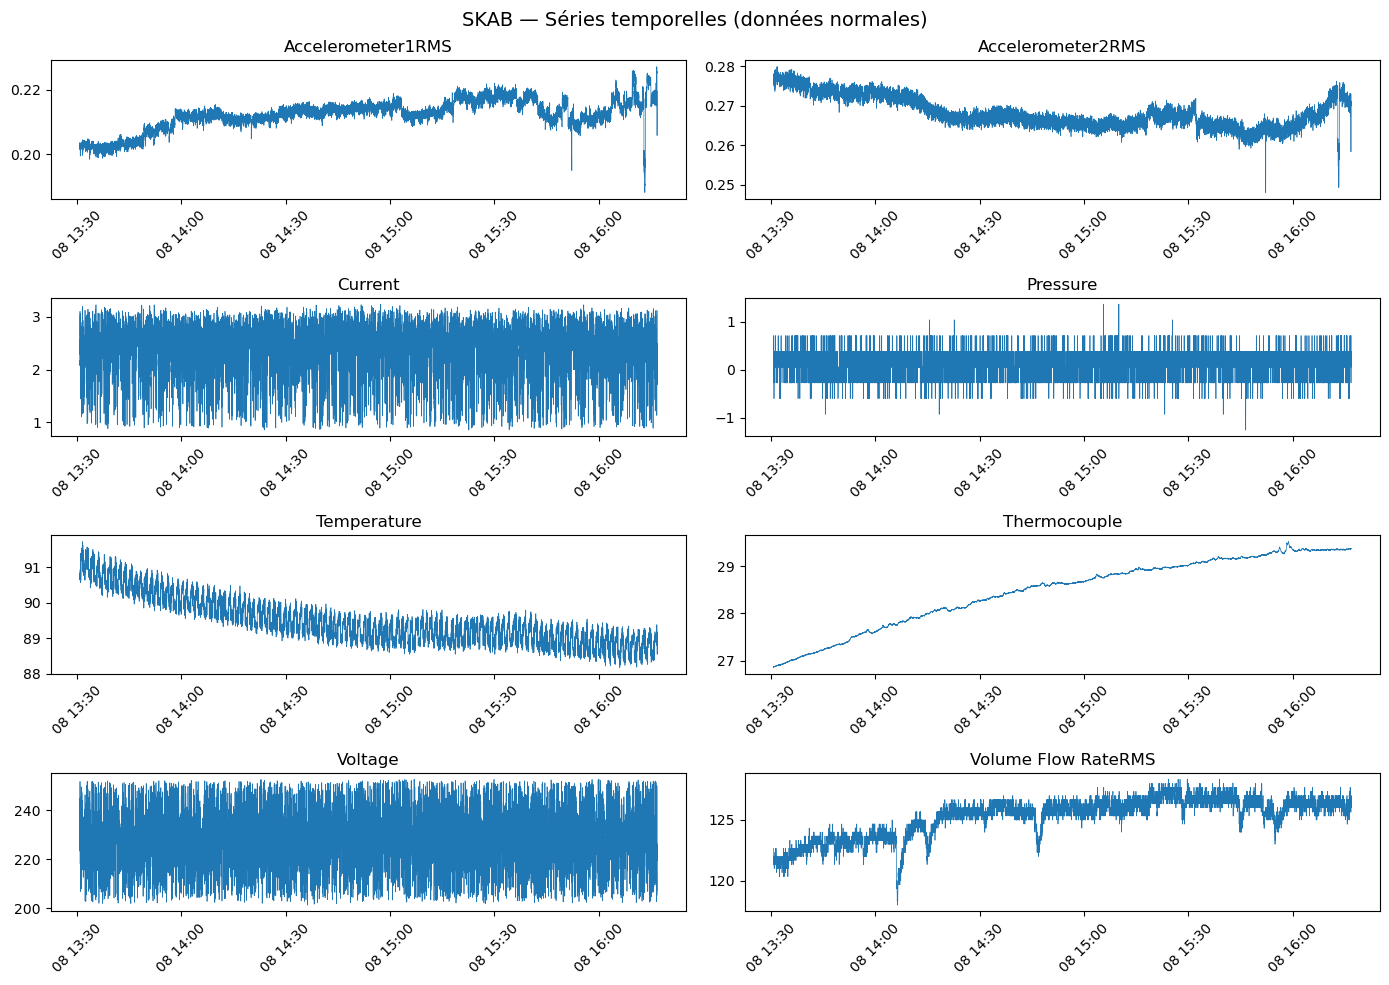

In [14]:
# Visualisation des séries temporelles
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df_skab.columns):
    axes[i].plot(df_skab.index, df_skab[col], linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('SKAB — Séries temporelles (données normales)', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Chargement des fichiers avec anomalies
import io
import requests

anomaly_urls = [
    "https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/1.csv",
    "https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/2.csv",
    "https://raw.githubusercontent.com/waico/SKAB/master/data/valve2/1.csv",
]

dfs_anomaly = []
for url in anomaly_urls:
    df_tmp = pd.read_csv(url, sep=';', index_col='datetime', parse_dates=True)
    dfs_anomaly.append(df_tmp)

df_with_anomalies = pd.concat(dfs_anomaly)

print(f"Shape : {df_with_anomalies.shape}")
print(f"Colonnes : {list(df_with_anomalies.columns)}")
print(f"\nDistribution des anomalies :")
print(df_with_anomalies['anomaly'].value_counts())
print(f"\nRatio anomalies : {df_with_anomalies['anomaly'].mean():.2%}")

Shape : (3283, 10)
Colonnes : ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']

Distribution des anomalies :
anomaly
0.0    2211
1.0    1072
Name: count, dtype: int64

Ratio anomalies : 32.65%
